# Part B: Mood Discovery with K-Means and PCA
Run the cells from top to bottom. Wait for each one to finish.

## Step 1: Load and clean the data

In [1]:
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

sns.set_style("whitegrid")

found = glob.glob("/kaggle/input/**/dataset.csv", recursive=True)
path = found[0] if found else "dataset.csv"
df = pd.read_csv(path)
df = df.drop(columns=["Unnamed: 0"], errors="ignore")
df = df.dropna()
df = df.drop_duplicates(subset="track_id").reset_index(drop=True)
df["is_hit"] = (df["popularity"] >= 50).astype(int)
print("Songs:", df.shape[0])

Songs: 89740


## Step 2: Pick the best number of moods (Elbow and Silhouette)

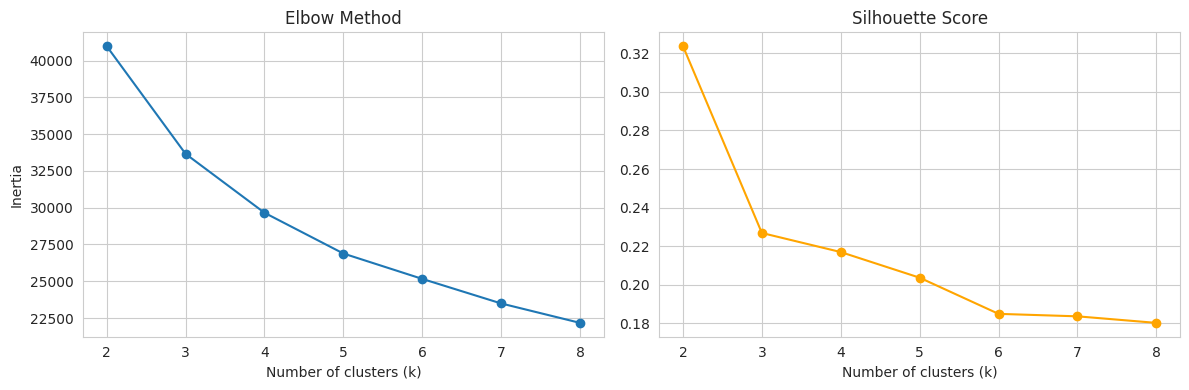

{2: np.float64(0.324), 3: np.float64(0.227), 4: np.float64(0.217), 5: np.float64(0.204), 6: np.float64(0.185), 7: np.float64(0.184), 8: np.float64(0.18)}


In [2]:
mood_features = ["danceability", "energy", "valence", "acousticness", "tempo", "loudness"]
X_mood = StandardScaler().fit_transform(df[mood_features])

sample_idx = np.random.RandomState(42).choice(len(X_mood), 10000, replace=False)
X_sample = X_mood[sample_idx]

ks = list(range(2, 9))
inertia = [KMeans(n_clusters=k, random_state=42, n_init=5).fit(X_sample).inertia_ for k in ks]
sil = [silhouette_score(X_sample, KMeans(n_clusters=k, random_state=42, n_init=5).fit(X_sample).labels_) for k in ks]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(ks, inertia, marker="o")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")
axes[1].plot(ks, sil, marker="o", color="orange")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Number of clusters (k)")
plt.tight_layout()
plt.show()
print(dict(zip(ks, np.round(sil, 3))))

## Step 3: Build 4 moods with K-Means
We use k = 4 so the moods are easy to explain. If your silhouette plot clearly prefers 3 or 5, change the number in the first line.

In [3]:
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_mood)
df["mood_cluster"] = kmeans.labels_

profile = df.groupby("mood_cluster")[mood_features].mean().round(2)
profile["songs"] = df["mood_cluster"].value_counts().sort_index()
print(profile.to_string())

              danceability  energy  valence  acousticness   tempo  loudness  songs
mood_cluster                                                                      
0                     0.70    0.74     0.70          0.20  120.83     -6.56  32420
1                     0.56    0.42     0.42          0.65  113.93    -10.38  22298
2                     0.47    0.82     0.32          0.07  136.19     -5.87  27323
3                     0.32    0.17     0.17          0.86  100.62    -20.55   7699


## Step 4: Name the moods automatically from their averages
The names come from the numbers in the table above. Check that they make sense. You can rename them in the dictionary if you disagree.

In [4]:
z = (profile[mood_features] - profile[mood_features].mean()) / profile[mood_features].std()
left = list(profile.index)
names = {}

c = (z.loc[left, "acousticness"] - z.loc[left, "energy"]).idxmax()
names[c] = "Calm Acoustic"
left.remove(c)

c = (z.loc[left, "energy"] + z.loc[left, "loudness"] + z.loc[left, "danceability"]).idxmax()
names[c] = "Party Energy"
left.remove(c)

c = z.loc[left, "valence"].idxmin()
names[c] = "Dark and Intense"
left.remove(c)

for c in left:
    names[c] = "Happy Groove"

df["mood"] = df["mood_cluster"].map(names)
print(names)
print(df["mood"].value_counts())

{np.int32(3): 'Calm Acoustic', np.int32(0): 'Party Energy', np.int32(2): 'Dark and Intense', 1: 'Happy Groove'}
mood
Party Energy        32420
Dark and Intense    27323
Happy Groove        22298
Calm Acoustic        7699
Name: count, dtype: int64


## Step 5: Mood map with PCA

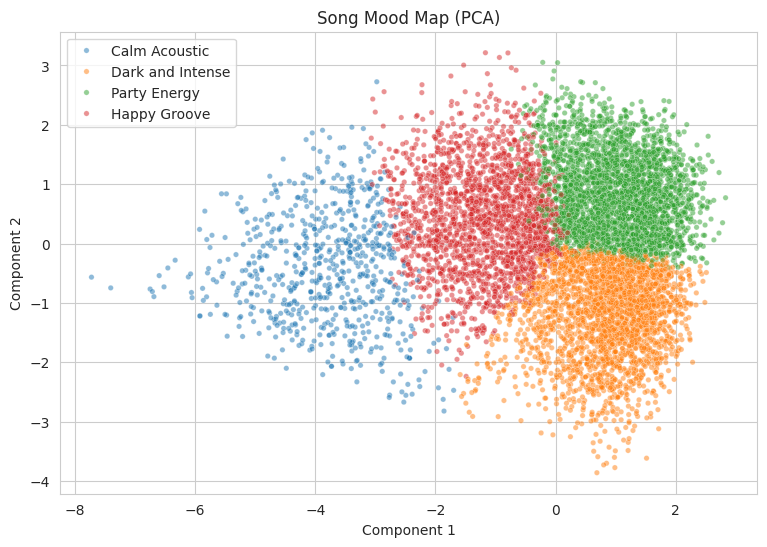

Variance explained by the 2 components: [0.45 0.22]


In [5]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_mood)

plot_idx = np.random.RandomState(1).choice(len(df), 8000, replace=False)
plt.figure(figsize=(9, 6))
sns.scatterplot(x=coords[plot_idx, 0], y=coords[plot_idx, 1],
                hue=df["mood"].iloc[plot_idx].values, alpha=0.5, s=15)
plt.title("Song Mood Map (PCA)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()
print("Variance explained by the 2 components:", pca.explained_variance_ratio_.round(2))

## Step 6: Are some moods more likely to be hits?

mood
Happy Groove        0.242
Dark and Intense    0.239
Party Energy        0.239
Calm Acoustic       0.199
Name: is_hit, dtype: float64


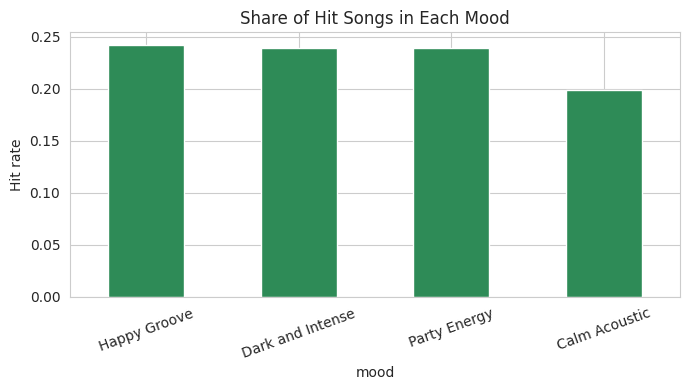

In [6]:
hit_rate = df.groupby("mood")["is_hit"].mean().round(3).sort_values(ascending=False)
print(hit_rate)
hit_rate.plot(kind="bar", color="seagreen", figsize=(7, 4))
plt.title("Share of Hit Songs in Each Mood")
plt.ylabel("Hit rate")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Step 7: Mood profile chart

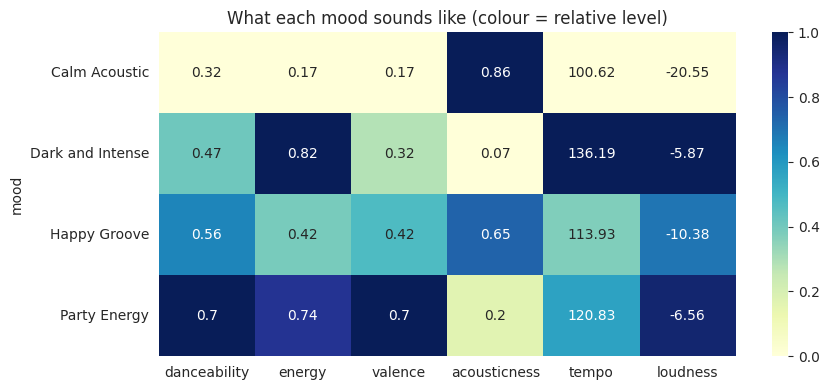

In [7]:
prof = df.groupby("mood")[mood_features].mean()
prof_scaled = (prof - prof.min()) / (prof.max() - prof.min())
plt.figure(figsize=(9, 4))
sns.heatmap(prof_scaled, annot=prof.round(2), fmt="", cmap="YlGnBu")
plt.title("What each mood sounds like (colour = relative level)")
plt.tight_layout()
plt.show()